In [1]:
import pandas as pd
import re
import plotly.express as px
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.dates as mdates

In [2]:
def get_year(x):
    l = re.findall('\d+',x)
    if len(l) > 0:
        return l[0]
    return None

In [3]:
df = pd.read_csv("scaling_laws.csv")

In [4]:
df['Year'] = df['Paper'].apply(get_year)
df = df[pd.notnull(df.Year)].reset_index(drop=True)

In [5]:
df.Year = df.Year.astype(int)

In [6]:
df = df.sort_values(['Year'],ascending=[True]).reset_index(drop=True)

In [7]:
import seaborn as sns

In [8]:
df2 = df.groupby(['Year'])['Paper'].count().reset_index(drop=False)

/var/folders/pz/5lsvsk5s79q_8bbzj9jj5vv00000gn/T/ipykernel_50008/1670913839.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df2.Year.unique())


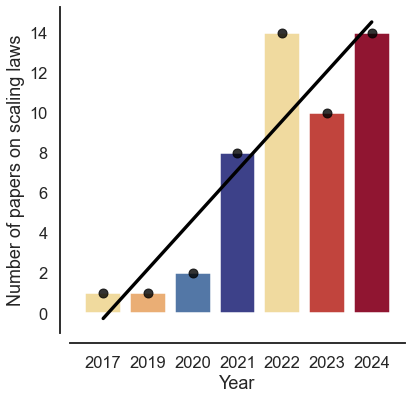

In [10]:
palette = ["#fee090", "#fdae61", "#4575b4", "#313695", "#fee091", "#d73027", "#a50026"]

fig = plt.figure(figsize=(6,6))
sns.set(style="white", context="talk")
ax = sns.barplot(data=df2, x=df2.Year, y=df2.Paper, hue='Year', palette=palette)
# put bars in background:

for c in ax.patches:
    c.set_zorder(0)
# plot regplot with numbers 0,..,len(a) as x value

plt.legend().remove()
sns.regplot(x=np.arange(0,len(df2)), y=df2.Paper, ax=ax, ci=None, color='black')
sns.despine(offset=10, trim=False)
ax.set_ylabel("Number of papers on scaling laws")
ax.set_xticklabels(df2.Year.unique())

plt.savefig("motivation.pdf",dpi=300, bbox_inches='tight')

/var/folders/pz/5lsvsk5s79q_8bbzj9jj5vv00000gn/T/ipykernel_50008/3998581687.py:9: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  ax = sns.barplot(data=df2, x=df2.Year, y=df2.Paper, hue='Year', palette=palette)
/var/folders/pz/5lsvsk5s79q_8bbzj9jj5vv00000gn/T/ipykernel_50008/3998581687.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df2.Year.unique())


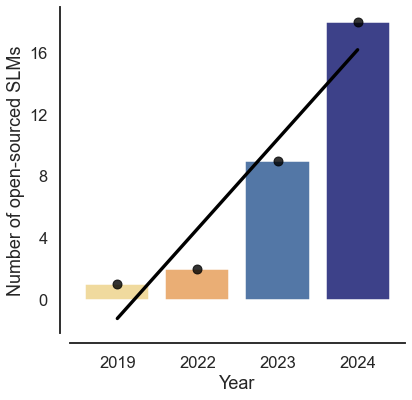

In [11]:
df2 = pd.DataFrame()
df2['Year'] = [2019, 2022, 2023, 2024]
df2['Paper'] = [1, 2, 9, 18]

palette = ["#fee090", "#fdae61", "#4575b4", "#313695", "#fee091", "#d73027", "#a50026"]

fig = plt.figure(figsize=(6,6))
sns.set(style="white", context="talk")
ax = sns.barplot(data=df2, x=df2.Year, y=df2.Paper, hue='Year', palette=palette)
# put bars in background:

for c in ax.patches:
    c.set_zorder(0)
# plot regplot with numbers 0,..,len(a) as x value

plt.legend().remove()
sns.regplot(x=np.arange(0,len(df2)), y=df2.Paper, ax=ax, ci=None, color='black')
sns.despine(offset=10, trim=False)
ax.set_ylabel("Number of open-sourced SLMs")

ax.set_xticklabels(df2.Year.unique())
ax.set_yticks([0,4,8,12,16])

plt.savefig("slm_motivation.pdf",dpi=300, bbox_inches='tight')

In [12]:
import argparse
import json
import pandas as pd

from model import LLM
from embodied import hardware_list

In [13]:
models_df = pd.read_csv("./data/database.csv").iloc[1:2]

print("operational carbon footprint validation")

for index_x in range(0, len(models_df.index)):
    model_row = models_df.iloc[index_x]

    model = LLM(
        model_row["name"],
        model_row["type"],
        model_row["parameter # (B)"],
        model_row["base model param. # (B)"],
        model_row["token # (B)"],
        model_row["CO2eq/KWh"],
        model_row["PUE"],
        model_row["computing device"],
        model_row["device TPD (W)"],
        model_row["avg. system power (W)"],
        model_row["peak TFLOPs/s"],
        model_row["achieved TFLOPs/s"],
        model_row["hardware efficiency"],
        model_row["device #"],
        model_row["total zettaFLOPs"],
        model_row["training days"],
        model_row["actual tCO2eq"],
    )
    model.training_co2eq()
    model.inference_co2eq()
    print(model.name + "\t" + str(model.train_delta))

hardware_df = pd.read_csv("./data/hardware.csv")
hard_list = hardware_list(hardware_df)

print("\n\n")

print("embodied carbon footprint validation")
hard_list.embodied_co2eq(20.4, 0.66)
print(hard_list.total_embodied_co2eq)

operational carbon footprint validation
GPT3	0.00225442863749592



embodied carbon footprint validation
-0.018112924533001284


In [14]:
def funL(N,D,alphaN=0.076, alphaD=0.103, Nc=6.4*10**13, Dc=1.8*10**13):
    term = (Nc/N)**(alphaN/alphaD) + (Dc/D)
    return term**alphaD

In [15]:
def funD(L,N,alphaN=0.076, alphaD=0.103, Nc=6.4*10**13, Dc=1.8*10**13):
    term = L**(1/alphaD) - (Nc/N)**(alphaN/alphaD)
    return Dc/term

In [16]:
def Lbound(N,alphaN=0.076, alphaD=0.103, Nc=6.4*10**13, Dc=1.8*10**13):
    return (Nc/N)**alphaN

In [17]:
def Lbound2(D,alphaN=0.076, alphaD=0.103, Nc=6.4*10**13, Dc=1.8*10**13):
    return (Dc/D)**alphaD

In [18]:
x = np.arange(1,100,5)
y = list(map(Lbound, x*10**9))

In [19]:
x2 = np.arange(100,10000,500)
y2 = list(map(Lbound2, x2*10**9))

In [20]:
y12 = []

for i in x:
    model = LLM(
        model_row["name"],
        model_row["type"],
        float(i),
        model_row["base model param. # (B)"],
        model_row["token # (B)"],
        model_row["CO2eq/KWh"],
        model_row["PUE"],
        model_row["computing device"],
        model_row["device TPD (W)"],
        model_row["avg. system power (W)"],
        model_row["peak TFLOPs/s"],
        model_row["achieved TFLOPs/s"],
        model_row["hardware efficiency"],
        model_row["device #"],
        model_row["total zettaFLOPs"],
        model_row["training days"],
        model_row["actual tCO2eq"],
    )
    model.training_co2eq()
    model.inference_co2eq()
    y12.append(model.predicted_co2eq_train)

In [21]:
y22 = []

for i in x2:
    model = LLM(
        model_row["name"],
        model_row["type"],
        model_row["parameter # (B)"],
        model_row["base model param. # (B)"],
        float(i),
        model_row["CO2eq/KWh"],
        model_row["PUE"],
        model_row["computing device"],
        model_row["device TPD (W)"],
        model_row["avg. system power (W)"],
        model_row["peak TFLOPs/s"],
        model_row["achieved TFLOPs/s"],
        model_row["hardware efficiency"],
        model_row["device #"],
        model_row["total zettaFLOPs"],
        model_row["training days"],
        model_row["actual tCO2eq"],
    )
    model.training_co2eq()
    model.inference_co2eq()
    y22.append(model.predicted_co2eq_train)

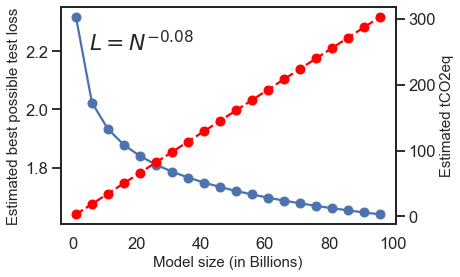

In [22]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.text(5, 2.2, '$L=N^{-0.08}$', fontsize = 22)

lns1 = ax.plot(x, y, '-o')
ax2 = ax.twinx()
lns3 = ax2.plot(x, y12, '--o', color='red')

#ax.grid()
ax.set_xlabel("Model size (in Billions)", fontsize=15)
ax.set_ylabel("Estimated best possible test loss", fontsize=15)
ax2.set_ylabel("Estimated tCO2eq", fontsize=15)
plt.savefig("paramwise.pdf",dpi=300, bbox_inches='tight')

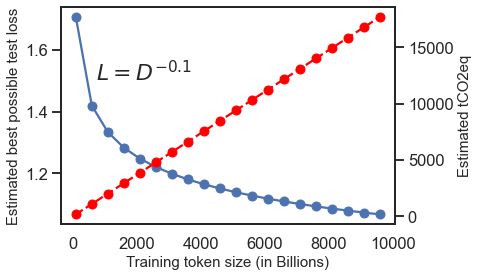

In [23]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.text(-10, 1.5, '    $L=D^{-0.1}$', fontsize = 22)

lns1 = ax.plot(x2, y2, '-o')
ax2 = ax.twinx()
lns3 = ax2.plot(x2, y22, '--o', color='red')


#ax.grid()
ax.set_xlabel("Training token size (in Billions)", fontsize=15)
ax.set_ylabel("Estimated best possible test loss", fontsize=15)
ax2.set_ylabel("Estimated tCO2eq", fontsize=15)
plt.savefig("datawise.pdf",dpi=300, bbox_inches='tight')